# Lab 1
## Dynamic model of a multi-link manipulator

**Robot selected:** UR5 (Universal Robots 5)

The UR5 is a 6-DOF industrial manipulator. In this lab we will:
1. Load the UR5 model and view its DH parameters
2. Fill in the physical parameters of each link
3. Set and display initial and final configurations
4. Plan a trajectory between them
5. Solve inverse dynamics for 3 scenarios
6. Compute the M, C, G matrices at each time step
7. Plot the joint torques for each scenario

## Steps

### 0. Import the necessary libraries

In [3]:
!pip install roboticstoolbox-python

  Using cached roboticstoolbox_python-1.1.1.tar.gz (1.5 MB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached spatialmath_python-1.1.15-py3-none-any.whl.metadata (17 kB)
  Using cached spatialgeometry-1.1.0-cp39-cp39-macosx_11_0_arm64.whl.metadata (4.5 kB)
  Using cached pgraph_python-0.6.3-py3-none-any.whl.metadata (7.5 kB)
  Using cached ansitable-0.11.5-py3-none-any.whl.metadata (28 kB)
  Using cached swift_sim-1.1.0-cp39-cp39-macosx_11_0_arm64.whl.metadata (8.3 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.7/114.7 MB 4.6 MB/s  0:00:250:00:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 5.6 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 5.4 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [4]:
from math import pi
import numpy as np
import roboticstoolbox as rtb
import matplotlib.pyplot as plt

### 1. Import robot model — UR5

We load the UR5 model from the Robotics Toolbox and print its Denavit-Hartenberg  parameters.



In [5]:
robot = rtb.models.DH.UR5()
print(robot)

DHRobot: UR5 (by Universal Robotics), 6 joints (RRRRRR), dynamics, standard DH parameters
┌─────┬─────────┬─────────┬────────┐
│ θⱼ  │   dⱼ    │   aⱼ    │   ⍺ⱼ   │
├─────┼─────────┼─────────┼────────┤
│  q1 │ 0.08946 │       0 │  90.0° │
│  q2 │       0 │  -0.425 │   0.0° │
│  q3 │       0 │ -0.3922 │   0.0° │
│  q4 │  0.1091 │       0 │  90.0° │
│  q5 │ 0.09465 │       0 │ -90.0° │
│  q6 │  0.0823 │       0 │   0.0° │
└─────┴─────────┴─────────┴────────┘

┌──┬──┐
└──┴──┘

┌──────┬───────┬─────┬─────┬─────┬──────┬─────┐
│ name │ q0    │ q1  │ q2  │ q3  │ q4   │ q5  │
├──────┼───────┼─────┼─────┼─────┼──────┼─────┤
│   qr │  180° │  0° │  0° │  0° │  90° │  0° │
│   qz │  0°   │  0° │  0° │  0° │  0°  │  0° │
└──────┴───────┴─────┴─────┴─────┴──────┴─────┘



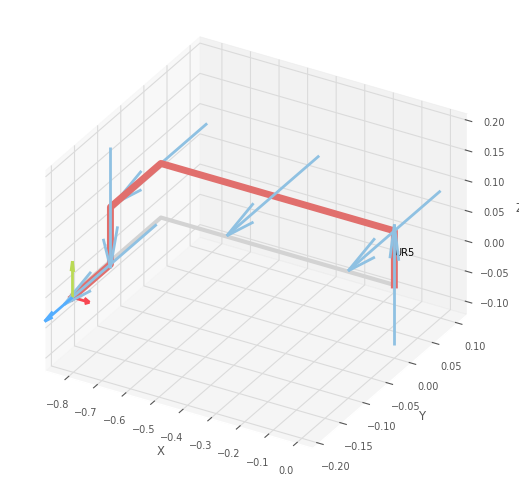

<Figure size 640x480 with 0 Axes>

In [6]:
# Display the robot in its zero (home) configuration
robot.plot(robot.qz)
plt.show()

### 2. Fill in the parameters of the robot model

We specify the physical properties of each link based on the UR5 datasheet.

The parameters needed are:
- **m** — mass of link (kg)
- **r** — position of center of mass (m)
- **I** — inertia tensor [Ixx, Iyy, Izz, Ixy, Iyz, Ixz]
- **Jm** — motor (drive) moment of inertia
- **B** — viscous friction coefficient of the drive
- **Tc** — Coulomb friction coefficient [positive, negative]
- **G** — gear ratio of the reducer
- **qlim** — joint angle limits [min, max] in radians

In [ ]:
print(robot.links[0].dyn())    # initial dynamic parameters of the first link

m     =       3.7 
r     =         0   -0.026   0.0019 
        |        0        0        0 | 
I     = |        0        0        0 | 
        |        0        0        0 | 
Jm    =         0 
B     =         0 
Tc    =         0(+)        0(-) 
G     =         1 
qlim  =         0 to        0


1. Let's define the mass of the links

In [ ]:
robot.links[0].m = 3.7
robot.links[1].m = 8.393
robot.links[2].m = 2.275
robot.links[3].m = 1.219
robot.links[4].m = 1.219
robot.links[5].m = 0.1879

2. Let's define the center of mass of each link

In [ ]:
robot.links[0].r = [0.0, -0.02561, 0.00193]
robot.links[1].r = [0.2125, 0.0, 0.11336]
robot.links[2].r = [0.11993, 0.0, 0.0265]
robot.links[3].r = [0.0, -0.0018, 0.01634]
robot.links[4].r = [0.0, 0.0018, 0.01634]
robot.links[5].r = [0.0, 0.0, -0.001159]

3. Let's define the inertia tensor of each link. Filling: [Lxx, Lyy, Lzz, Lxy, Lyz, Lxz]

In [ ]:
robot.links[0].I = [0.010267, 0.010267, 0.00666, 0, 0, 0]
robot.links[1].I = [0.22689,  0.22689,  0.01511, 0, 0, 0]
robot.links[2].I = [0.049443, 0.049443, 0.004095, 0, 0, 0]
robot.links[3].I = [0.001111, 0.001111, 0.000219, 0, 0, 0]
robot.links[4].I = [0.001111, 0.001111, 0.000219, 0, 0, 0]
robot.links[5].I = [0.000171, 0.000171, 0.000034, 0, 0, 0]

4. Let's set the moment of inertia of the drive

In [ ]:
robot.links[0].Jm = 0.0001
robot.links[1].Jm = 0.0001
robot.links[2].Jm = 0.0001
robot.links[3].Jm = 0.000033
robot.links[4].Jm = 0.000033
robot.links[5].Jm = 0.000033

5. Let's define the coefficient of viscous friction of the drive

In [ ]:
robot.links[0].B = 0.0015
robot.links[1].B = 0.0015
robot.links[2].B = 0.0015
robot.links[3].B = 0.0007
robot.links[4].B = 0.0007
robot.links[5].B = 0.0007

6. Let's define the coefficient of Coulomb friction of the drive

In [ ]:
robot.links[0].Tc = [0.395, -0.435]
robot.links[1].Tc = [0.395, -0.435]
robot.links[2].Tc = [0.132, -0.105]
robot.links[3].Tc = [0.011, -0.017]
robot.links[4].Tc = [0.011, -0.017]
robot.links[5].Tc = [0.004, -0.010]

7. Let's set the gear ratio for each link

In [ ]:
robot.links[0].G = 101.0
robot.links[1].G = 101.0
robot.links[2].G = 101.0
robot.links[3].G = 54.0
robot.links[4].G = 54.0
robot.links[5].G = 54.0

8. Let's set restrictions on the generalized coordinates for each link

In [ ]:
robot.links[0].qlim = [-2*pi, 2*pi]
robot.links[1].qlim = [-2*pi, 2*pi]
robot.links[2].qlim = [-pi,   pi]
robot.links[3].qlim = [-2*pi, 2*pi]
robot.links[4].qlim = [-2*pi, 2*pi]
robot.links[5].qlim = [-2*pi, 2*pi]

In [17]:
# Verify: print updated parameters for link 0
print(robot.links[0].dyn())

m     =       3.7 
r     =         0   -0.026   0.0019 
        |     0.01        0        0 | 
I     = |        0     0.01        0 | 
        |        0        0   0.0067 | 
Jm    =    0.0001 
B     =    0.0015 
Tc    =       0.4(+)    -0.43(-) 
G     =     1e+02 
qlim  =      -6.3 to      6.3


### 3. Set the initial and final positions of the robot and plot them

We choose arbitrary start and end configurations 


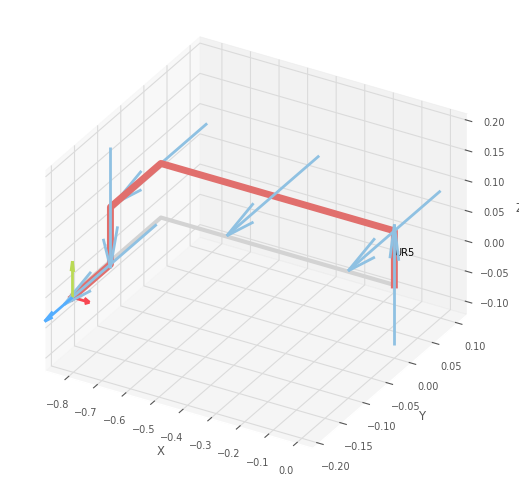

<Figure size 640x480 with 0 Axes>

In [ ]:
# Initial configuration — all joints at 0 
q_start = [0, 0, 0, 0, 0, 0]
robot.plot(q_start)
plt.show()

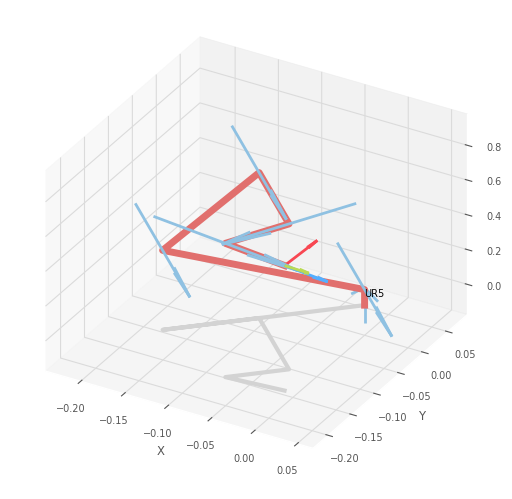

<Figure size 640x480 with 0 Axes>

In [ ]:
# Final configuration ，arbitrary joint angles
q_end = [pi/4, -pi/3, -pi/4, pi/3, -pi/3, pi/4]
robot.plot(q_end)
plt.show()

### 4. Plan the trajectory with prebuilt functions

We use "rtb.jtraj()" to plan a smooth trajectory in joint space between "q_start "and "q_end".



The result contains:
- tr.q ：joint positions 
- tr.qd ： joint velocities
- tr.qdd ： joint accelerations

In [54]:
N = 100          # number of time steps
t_start = 0
t_stop = 5       # motion duration in seconds
t_step = t_stop / N
time = np.arange(t_start, t_stop, t_step)

# Plan trajectory
tr = rtb.jtraj(q_start, q_end, time)

print("Shape of q:",   tr.q.shape)    
print("Shape of qd:",  tr.qd.shape)   
print("Shape of qdd:", tr.qdd.shape)  

Shape of q: (100, 6)
Shape of qd: (100, 6)
Shape of qdd: (100, 6)


### 5. Solve the inverse dynamics using the Newton-Euler method

We use "robot.rne()" (Recursive Newton-Euler) to compute the joint torques required for each scenario.



In [49]:
# Scenario 1: non-zero "dotq","ddotq"
tau_1 = robot.rne(tr.q, tr.qd, tr.qdd).T

# Scenario 2: non-zero velocities and negligible accelerations
tau_2 = robot.rne(tr.q, tr.qd, np.zeros([N, 6])).T

# Scenario 3: zero "dotq","ddotq", maintaining a given position
tau_3 = robot.rne(tr.q, np.zeros([N, 6]), np.zeros([N, 6])).T

print("tau_1 shape:", tau_1.shape)  
print("tau_2 shape:", tau_2.shape)
print("tau_3 shape:", tau_3.shape)

tau_1 shape: (6, 100)
tau_2 shape: (6, 100)
tau_3 shape: (6, 100)


### 6. Obtain the components of the dynamic equation

The general equation of motion is Newton-Euler:

$$\tau = M(q)\ddot{q} + C(q, \dot{q})\dot{q} + G(q)$$

Where:
- **M(q)** — inertia matrix (6×6)
- **C(q, q̇)** — Coriolis/centrifugal matrix (6×6)
- **G(q)** — gravity vector (6×1)

In [50]:
M = robot.inertia(tr.q)          
C = robot.coriolis(tr.q, tr.qd)  
G = robot.gravload(tr.q)         

# Print the values at t=0 
print("M(q) at t=0:")
print(np.round(M[0], 4))

print("\nC(q, qd) at t=0:")
print(np.round(C[0], 4))

print("\nG(q) at t=0:")
print(np.round(G[0], 4))

M(q) at t=0:
[[ 4.6968e+00  1.9700e-02  1.9700e-02  1.9700e-02 -6.7000e-03  0.0000e+00]
 [ 1.9700e-02  4.2922e+00  1.2918e+00  1.3900e-02 -3.3000e-03  0.0000e+00]
 [ 1.9700e-02  1.2918e+00  1.6108e+00  1.3900e-02 -3.3000e-03  0.0000e+00]
 [ 1.9700e-02  1.3900e-02  1.3900e-02  1.1010e-01 -3.3000e-03  0.0000e+00]
 [-6.7000e-03 -3.3000e-03 -3.3000e-03 -3.3000e-03  9.9100e-02  0.0000e+00]
 [ 0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00  9.6300e-02]]

C(q, qd) at t=0:
[[0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]]

G(q) at t=0:
[ -0.     -54.1113 -16.182    0.       0.       0.    ]


In [51]:
# used in scenario 3
M0 = robot.inertia(tr.q)
C0 = robot.coriolis(tr.q, np.zeros([N, 6]))
G0 = robot.gravload(tr.q)

print("C0 (zero velocity) at t=0:")
print(np.round(C0[0], 4)) 

C0 (zero velocity) at t=0:
[[0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]]


### 7. Plot the graphs of joint torques for each scenario

We plot the torques for all 6 joints across the trajectory, for each of the 3 scenarios.



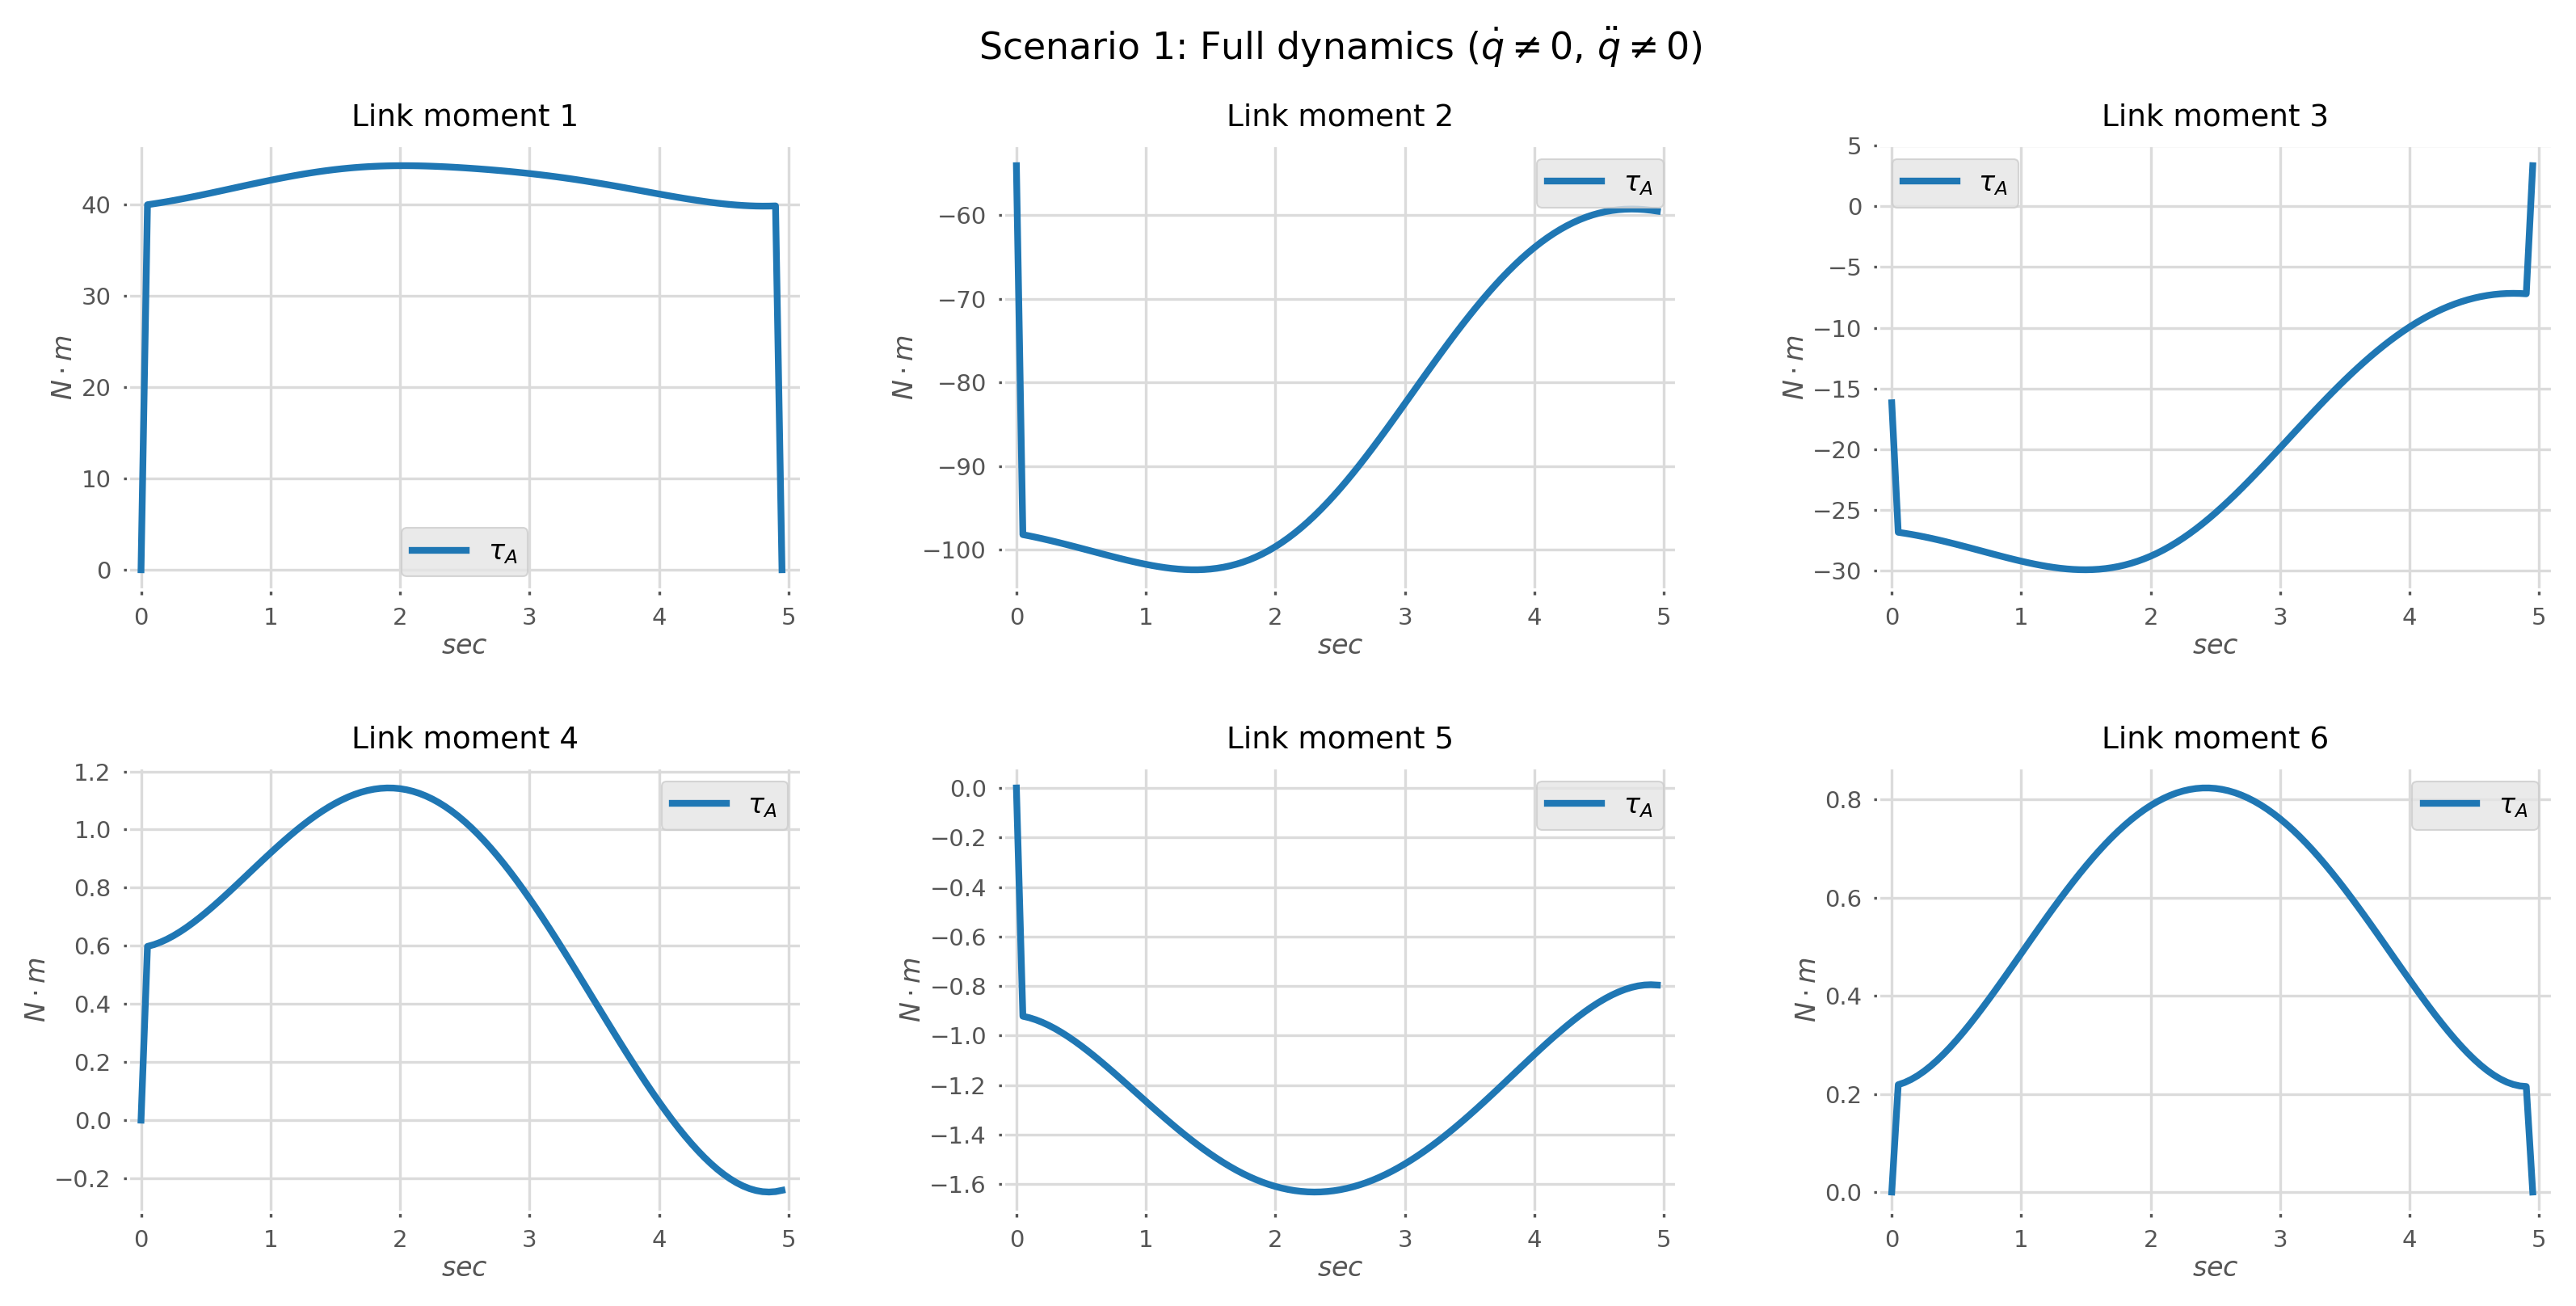

In [55]:
# ---- Scenario 1: Full dynamics ----
plt.figure(figsize=(10, 5), dpi=300)
plt.suptitle(r'Scenario 1: Full dynamics ($\dot{q} \neq 0$, $\ddot{q} \neq 0$)', fontsize=11)

for g in range(6):
    plt.subplot(2, 3, g + 1)
    plt.subplots_adjust(left=0, bottom=0, right=1, top=0.88, wspace=0.3, hspace=0.4)
    plt.plot(time, tau_A[g], linewidth=2, color='tab:blue', label=r'$\tau_A$')
    plt.title(f'Link moment {g+1}', fontsize=9)
    plt.ylabel(r'$N \cdot m$', fontsize=8)
    plt.xlabel(r'$sec$', fontsize=8)
    plt.grid(True)
    plt.legend(fontsize=8)
    ax = plt.gca()
    ax.set_facecolor((1, 1, 1))
    ax.set_xlim([t_start - 0.1, t_stop + 0.1])

plt.show()

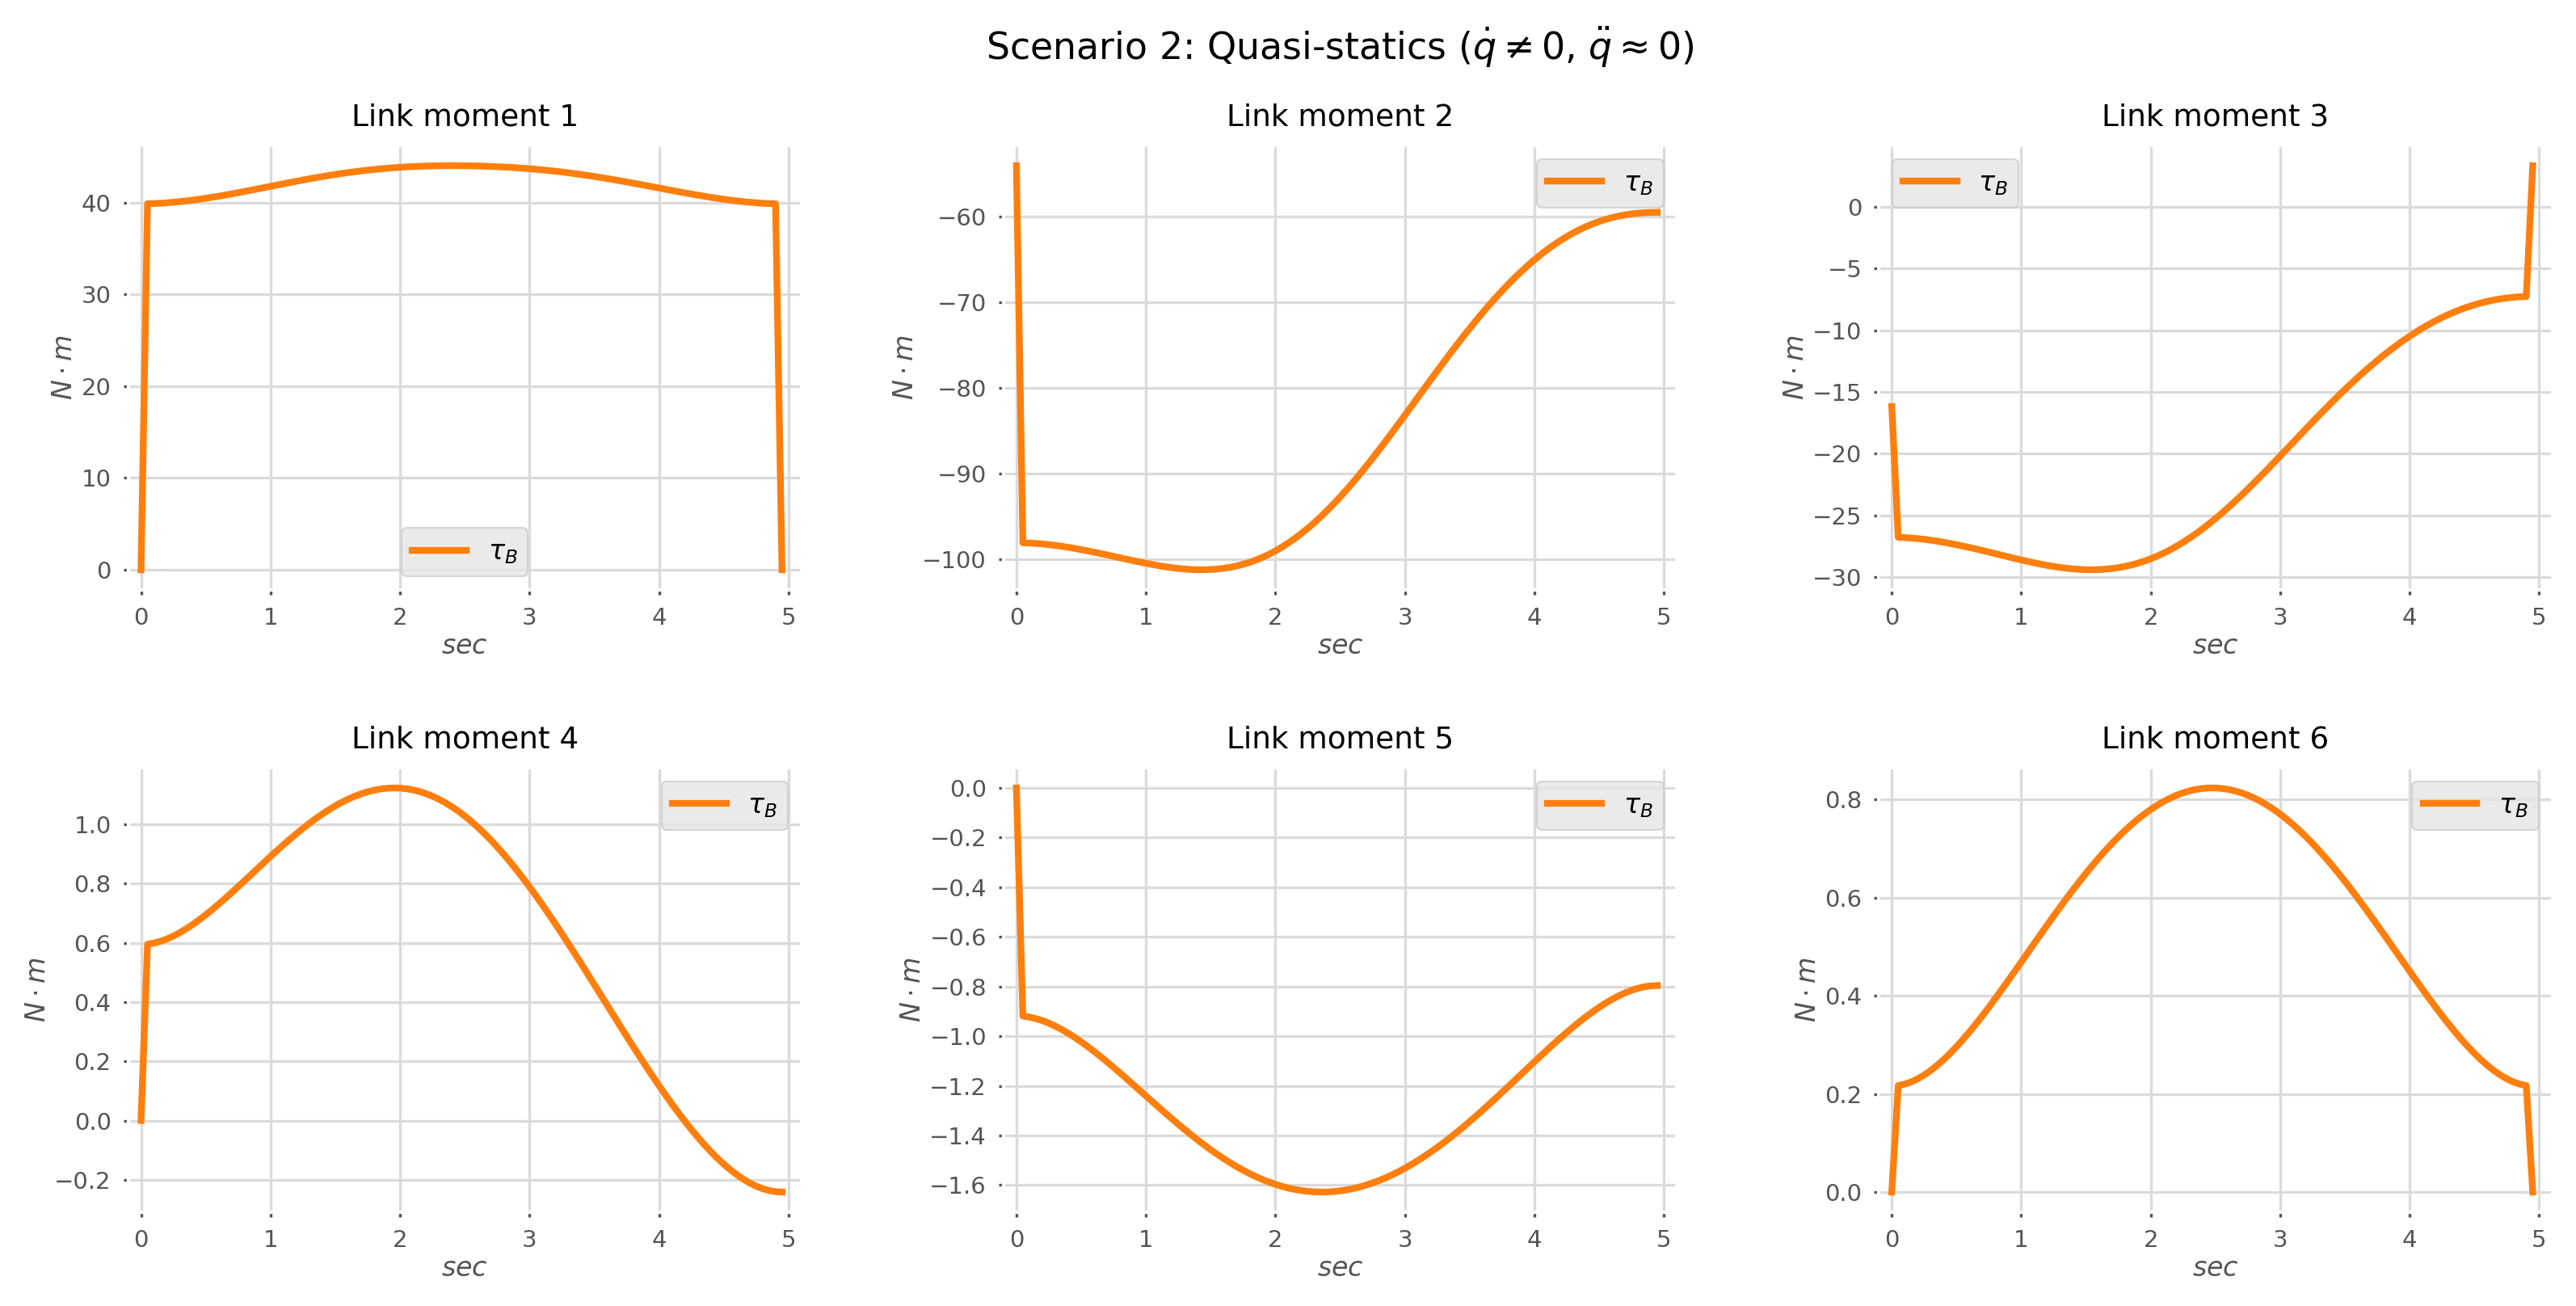

In [56]:
# ---- Scenario 2: Quasi-statics ----
plt.figure(figsize=(10, 5), dpi=300)
plt.suptitle(r'Scenario 2: Quasi-statics ($\dot{q} \neq 0$, $\ddot{q} \approx 0$)', fontsize=11)

for g in range(6):
    plt.subplot(2, 3, g + 1)
    plt.subplots_adjust(left=0, bottom=0, right=1, top=0.88, wspace=0.3, hspace=0.4)
    plt.plot(time, tau_B[g], linewidth=2, color='tab:orange', label=r'$\tau_B$')
    plt.title(f'Link moment {g+1}', fontsize=9)
    plt.ylabel(r'$N \cdot m$', fontsize=8)
    plt.xlabel(r'$sec$', fontsize=8)
    plt.grid(True)
    plt.legend(fontsize=8)
    ax = plt.gca()
    ax.set_facecolor((1, 1, 1))
    ax.set_xlim([t_start - 0.1, t_stop + 0.1])

plt.show()

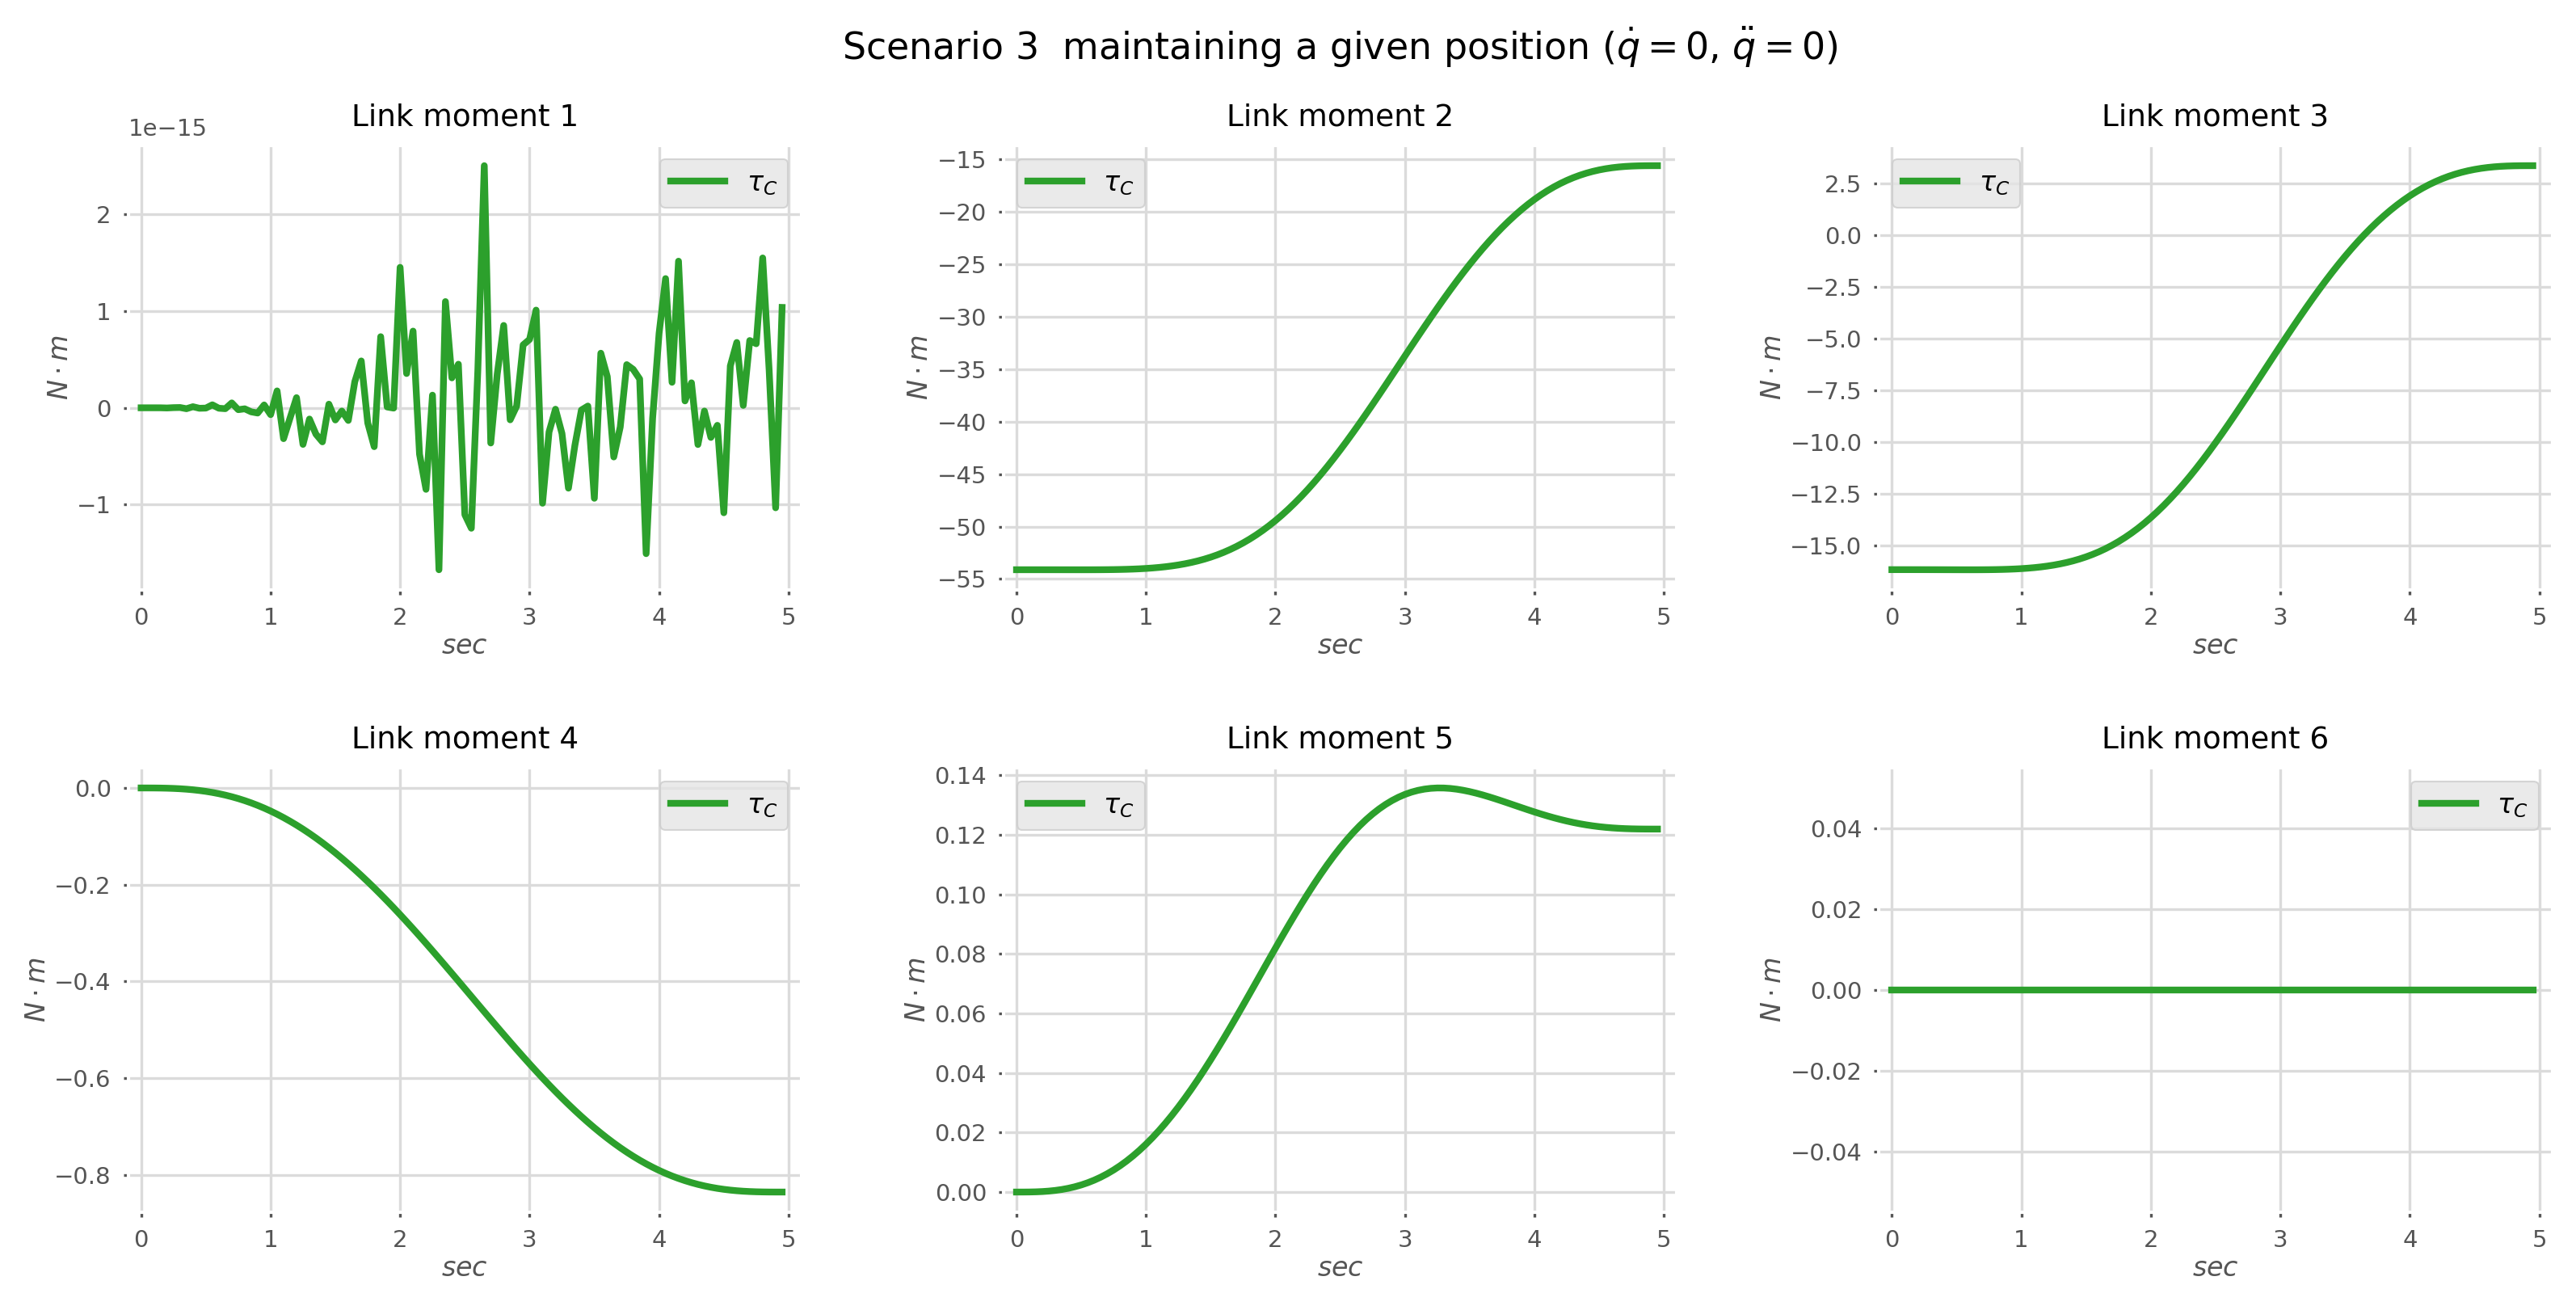

In [57]:
# ---- Scenario 3 maintaining a given position:----
plt.figure(figsize=(10, 5), dpi=300)
plt.suptitle(r'Scenario 3  maintaining a given position ($\dot{q} = 0$, $\ddot{q} = 0$)', fontsize=11)

for g in range(6):
    plt.subplot(2, 3, g + 1)
    plt.subplots_adjust(left=0, bottom=0, right=1, top=0.88, wspace=0.3, hspace=0.4)
    plt.plot(time, tau_C[g], linewidth=2, color='tab:green', label=r'$\tau_C$')
    plt.title(f'Link moment {g+1}', fontsize=9)
    plt.ylabel(r'$N \cdot m$', fontsize=8)
    plt.xlabel(r'$sec$', fontsize=8)
    plt.grid(True)
    plt.legend(fontsize=8)
    ax = plt.gca()
    ax.set_facecolor((1, 1, 1))
    ax.set_xlim([t_start - 0.1, t_stop + 0.1])

plt.show()

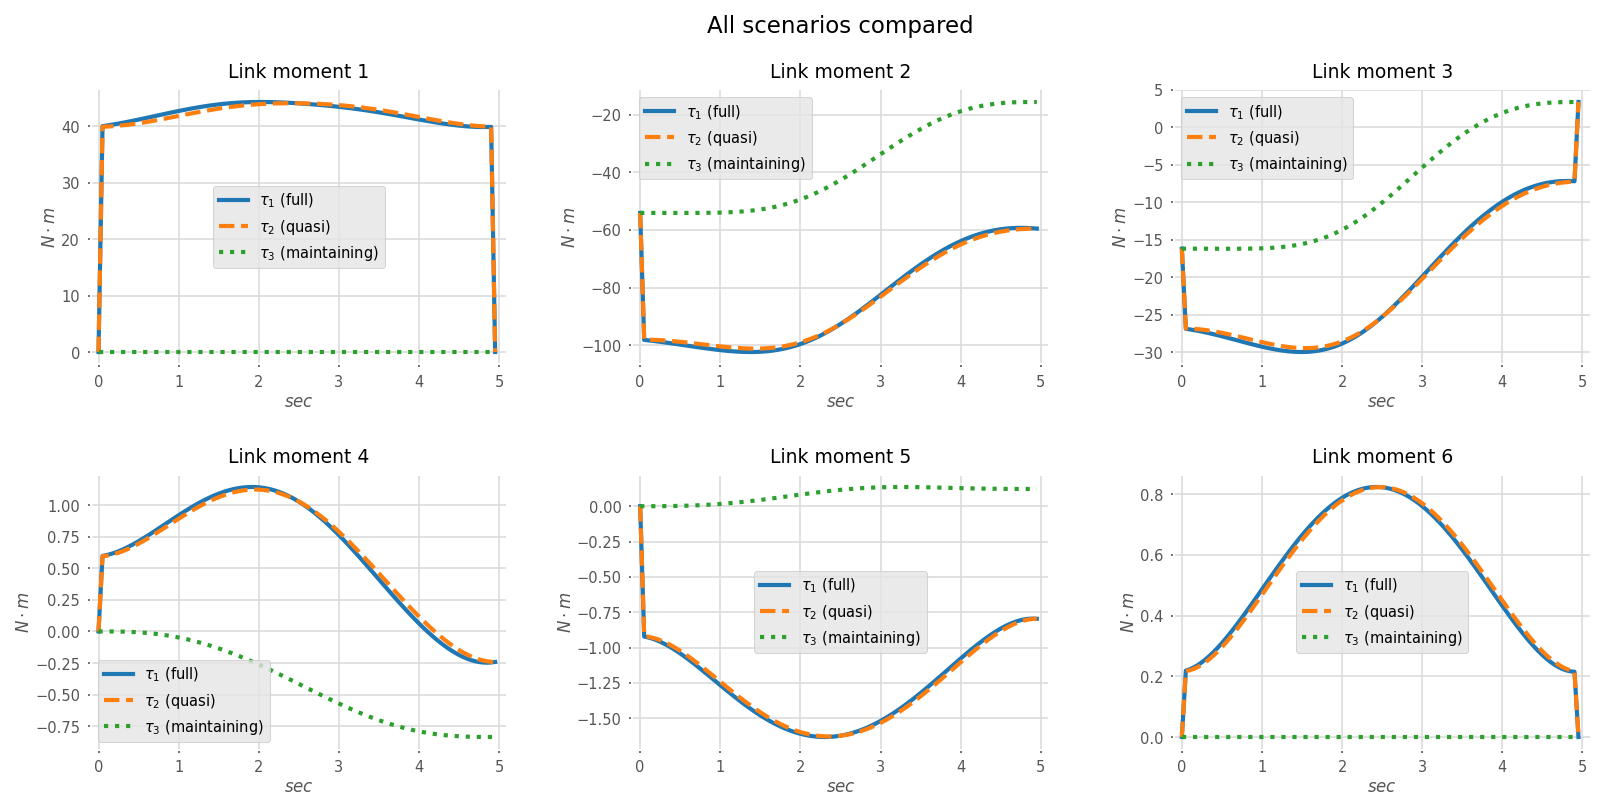

In [47]:
# ---- All 3 scenarios overlaid for comparison ----
plt.figure(figsize=(10, 5), dpi=150)
plt.suptitle('All scenarios compared', fontsize=11)

for g in range(6):
    plt.subplot(2, 3, g + 1)
    plt.subplots_adjust(left=0, bottom=0, right=1, top=0.88, wspace=0.3, hspace=0.4)
    plt.plot(time, tau_1[g], linewidth=2, label=r'$\tau_1$ (full)',   color='tab:blue')
    plt.plot(time, tau_2[g], linewidth=2, label=r'$\tau_2$ (quasi)',  color='tab:orange', linestyle='--')
    plt.plot(time, tau_3[g], linewidth=2, label=r'$\tau_3$ (maintaining)',   color='tab:green',  linestyle=':')
    plt.title(f'Link moment {g+1}', fontsize=9)
    plt.ylabel(r'$N \cdot m$', fontsize=8)
    plt.xlabel(r'$sec$', fontsize=8)
    plt.grid(True)
    plt.legend(fontsize=7)
    ax = plt.gca()
    ax.set_facecolor((1, 1, 1))
    ax.set_xlim([t_start - 0.1, t_stop + 0.1])

plt.show()

## Conclusions

The three inverse dynamics scenarios reveal how different motion conditions affect joint torques.
**Scenario 1 (full dynamics, $\dot{q}\neq0,\ \ddot{q}\neq0$)** produces the largest torques, 
driven by the inertia matrix $M(q)$ which contributes most at the start and end of the trajectory 
where accelerations peak. **Scenario 2 (quasi-statics, $\dot{q}\neq0,\ \ddot{q}\approx0$)** yields 
smaller torques since the acceleration terms vanish; the remaining effort comes from 
Coriolis/centrifugal effects $C(q,\dot{q})$ and gravity $G(q)$. **Scenario 3 (maintaining position, 
$\dot{q}=0,\ \ddot{q}=0$)** produces the smallest and smoothest torques, purely gravity-compensation, 
representing the minimum effort to hold the robot in place. The difference between Scenario 1 and 
Scenario 3 is the true *dynamic cost* of motion. Regarding the $M$, $C$, $G$ matrices: $M(q)$ is 
symmetric and positive definite, varying with configuration as mass distribution shifts; $C(q,\dot{q})$ 
becomes zero when velocity is zero, confirming that Coriolis/centrifugal forces only arise during motion; 
and $G(q)$ changes continuously along the trajectory, with Joint 2 carrying the heaviest gravitational 
load due to its lever arm geometry.